# RansomSense
## Notebook 5: Model Evaluation & Optimization

### Objective

The purpose of this notebook is to evaluate the performance of the trained machine learning models and improve the best-performing model through hyperparameter tuning.

The evaluation focuses on:

- Model performance metrics
- Cross-validation
- Hyperparameter optimization
- Prediction analysis
- Model comparison

The final optimized model will be saved for deployment.

In [1]:
import pandas as pd
import numpy as np

import joblib

import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("../data/processed/cleaned_ransomware_dataset.csv")

In [3]:
SEVERITY_FEATURES = [
    "Industry",
    "Country",
    "Attack_Date",
    "Ransomware_Group",
    "Attack_Vector",
    "Ransom_Amount_USD"
]

X = df[SEVERITY_FEATURES]

y = df["Severity_Score"]

In [4]:
X["Attack_Date"] = pd.to_datetime(X["Attack_Date"])

X["Attack_Year"] = X["Attack_Date"].dt.year
X["Attack_Month"] = X["Attack_Date"].dt.month
X["Attack_Day"] = X["Attack_Date"].dt.day
X["Attack_DayOfWeek"] = X["Attack_Date"].dt.dayofweek

X = X.drop("Attack_Date", axis=1)

In [5]:
categorical_features = X.select_dtypes(include="object").columns

numerical_features = X.select_dtypes(include=["int64","float64"]).columns

C:\Users\hlaku\AppData\Local\Temp\ipykernel_28208\701655839.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

X_train = preprocessor.fit_transform(X_train)

X_test = preprocessor.transform(X_test)

# Load Best Model

The best-performing model saved during Notebook 4 is loaded for evaluation and optimization.

In [8]:
model = joblib.load("../models/severity_model.pkl")

# Initial Model Performance

The model is evaluated on the unseen testing dataset using common regression metrics.

In [9]:
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

MAE : 2.577
RMSE: 3.047
R²  : 0.164


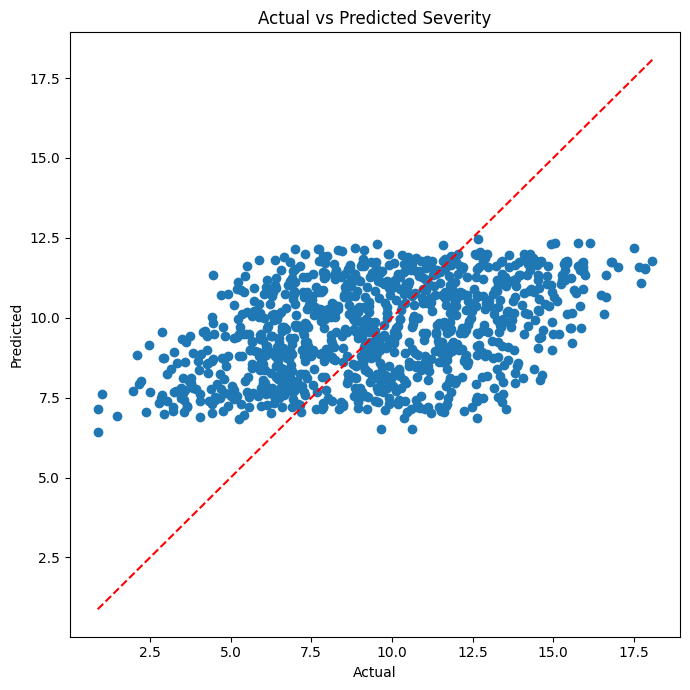

In [10]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted Severity")

plt.tight_layout()

plt.savefig("../images/model_predictions.png", dpi=300)

plt.show()

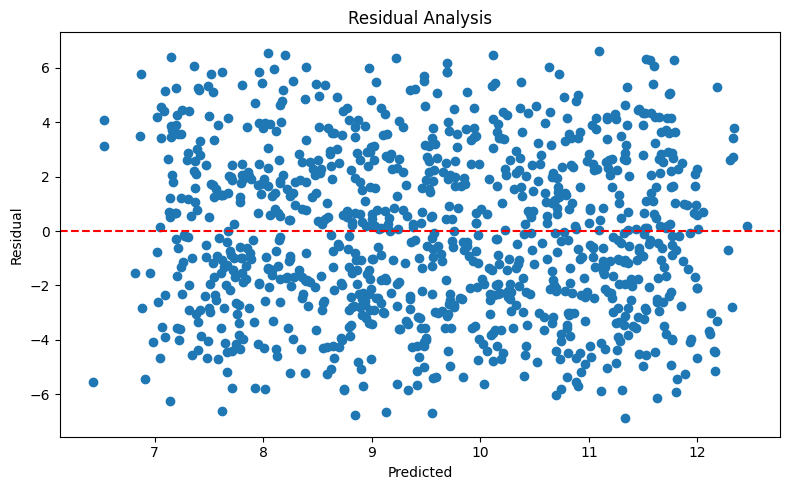

In [11]:
residuals = y_test - predictions

plt.figure(figsize=(8,5))

plt.scatter(predictions, residuals)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Analysis")

plt.tight_layout()

plt.savefig("../images/residual_analysis.png", dpi=300)

plt.show()

# Cross Validation

Cross-validation provides a more robust estimate of model performance by evaluating the model across multiple data splits.

In [12]:
cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print(cv_scores)

print("Average:", cv_scores.mean())

[0.19081934 0.17647523 0.17341902 0.18685904 0.16900052]
Average: 0.17931462933168196


# Hyperparameter Tuning

Grid Search is used to identify the optimal combination of model parameters.

In [13]:
parameters = {

    "n_estimators":[100,200],

    "max_depth":[10,20,None],

    "min_samples_split":[2,5],

    "min_samples_leaf":[1,2]

}

In [14]:
grid = GridSearchCV(

    estimator=RandomForestRegressor(random_state=42),

    param_grid=parameters,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate

In [15]:
print(grid.best_params_)

print(grid.best_score_)

{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
0.15473841021878293


In [16]:
best_model = grid.best_estimator_

pred = best_model.predict(X_test)

mae2 = mean_absolute_error(y_test,pred)

rmse2 = np.sqrt(mean_squared_error(y_test,pred))

r22 = r2_score(y_test,pred)

In [17]:
comparison = pd.DataFrame({

    "Metric":[
        "MAE",
        "RMSE",
        "R²"
    ],

    "Before":[
        mae,
        rmse,
        r2
    ],

    "After":[
        mae2,
        rmse2,
        r22
    ]

})

comparison

,Metric,Before,After
0,MAE,2.577104,2.604823
1,RMSE,3.046866,3.087699
2,R²,0.163740,0.141175


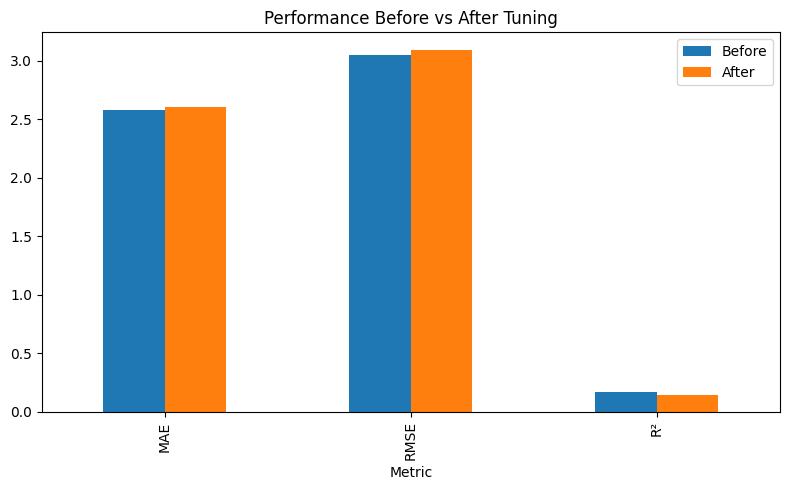

In [18]:
comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Performance Before vs After Tuning")

plt.tight_layout()

plt.savefig("../images/performance_comparison.png", dpi=300)

plt.show()

In [19]:
joblib.dump(
    best_model,
    "../models/optimized_severity_model.pkl"
)

['../models/optimized_severity_model.pkl']

# Conclusion

The trained severity prediction model was successfully evaluated and optimized.

Key achievements:

- Evaluated model performance using MAE, RMSE, and R².
- Visualized prediction accuracy and residual errors.
- Performed 5-fold cross-validation.
- Tuned model hyperparameters using Grid Search.
- Compared model performance before and after optimization.
- Saved the optimized model for deployment.

The optimized model is now ready for interpretation using Explainable AI techniques in the next notebook.